# 6 Fine-tuning for classification

## 6.2 Preparing the dataset

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

import pandas as pd

In [2]:
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extration.")
        return

    # 下载zip文件
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
    # unzip
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path) # 添加.tsv 后缀
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extration.


In [3]:
# 文件使用 tab 分割
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
print(df["Label"].value_counts())   #

Label
ham     4825
spam     747
Name: count, dtype: int64


大部分都是ham，后面需要匹配数量

In [5]:
print(df["Label"]=="spam")      # 判断每行是否是spam
print(df[df["Label"]=="spam"])  # 筛选所有spam行

0       False
1       False
2        True
3       False
4       False
        ...  
5567     True
5568    False
5569    False
5570    False
5571    False
Name: Label, Length: 5572, dtype: bool
     Label                                               Text
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
5     spam  FreeMsg Hey there darling it's been 3 week's n...
8     spam  WINNER!! As a valued network customer you have...
9     spam  Had your mobile 11 months or more? U R entitle...
11    spam  SIX chances to win CASH! From 100 to 20,000 po...
...    ...                                                ...
5537  spam  Want explicit SEX in 30 secs? Ring 02073162414...
5540  spam  ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547  spam  Had your contract mobile 11 Mnths? Latest Moto...
5566  spam  REMINDER FROM O2: To get 2.50 pounds free call...
5567  spam  This is the 2nd time we have tried 2 contact u...

[747 rows x 2 columns]


In [6]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    print(num_spam)
    # 随机对ham抽样，匹配spam的个数
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df

In [7]:
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

747
Label
ham     747
spam    747
Name: count, dtype: int64


In [8]:
# map 前
create_balanced_dataset(df)["Label"][:3]

747


,Label
4307,ham
4138,ham
4831,ham


In [9]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [10]:
print(len(balanced_df))
# 抽样所有，相当于打乱
shuffled = balanced_df.sample(frac=1)
print(shuffled[:3])
# 重置下标
shuffled = shuffled.reset_index(drop=True)  # drop=True 去除旧的下标列
print(shuffled[:3])

print(len(shuffled))

1494
      Label                                               Text
4526      0  Cos i was out shopping wif darren jus now n i ...
5124      0  He is impossible to argue with and he always t...
1017      1  FREE for 1st week! No1 Nokia tone 4 ur mob eve...
   Label                                               Text
0      0  Cos i was out shopping wif darren jus now n i ...
1      0  He is impossible to argue with and he always t...
2      1  FREE for 1st week! No1 Nokia tone 4 ur mob eve...
1494


In [11]:
def random_split(df, train_frac, validation_frac):
    # 分为 train, valid, test集，
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[: train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [12]:
train_df. to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [13]:
train_df

,Label,Text
0,0,Dude how do you like the buff wind.
1,0,Tessy..pls do me a favor. Pls convey my birthd...
2,1,Reminder: You have not downloaded the content ...
3,1,Got what it takes 2 take part in the WRC Rally...
4,1,"Shop till u Drop, IS IT YOU, either 10K, 5K, £..."
...,...,...
1040,1,4mths half price Orange line rental & latest c...
1041,1,Thanks for the Vote. Now sing along with the s...
1042,1,IMPORTANT INFORMATION 4 ORANGE USER 0796XXXXXX...
1043,1,Urgent! call 09066612661 from landline. Your c...


## 6.3 Creating data loaders

![text to padded token ids](https://raw.githubusercontent.com/ipdor/Pictures/master/20260502113416459.png)

In [14]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


在实例化数据加载器之前，我们首先需要实现一个 PyTorch Dataset，它指定了如何加载和处理数据


In [15]:
tks = [22, 21, 20]
pad = [31] * 3
print(tks + pad)

[22, 21, 20, 31, 31, 31]


In [16]:
data = pd.read_csv("train.csv")
print(data["Label"])   # 输出列
print(data[0:5])       # 输出行
# 使用 iloc 输出第一行
print(data.iloc[0])

0       0
1       0
2       1
3       1
4       1
       ..
1040    1
1041    1
1042    1
1043    1
1044    0
Name: Label, Length: 1045, dtype: int64
   Label                                               Text
0      0                Dude how do you like the buff wind.
1      0  Tessy..pls do me a favor. Pls convey my birthd...
2      1  Reminder: You have not downloaded the content ...
3      1  Got what it takes 2 take part in the WRC Rally...
4      1  Shop till u Drop, IS IT YOU, either 10K, 5K, £...
Label                                      0
Text     Dude how do you like the buff wind.
Name: 0, dtype: object


In [17]:
max_lens = max([len(x) for x in data["Text"]])
max_lens

458

In [18]:

tokens = [tokenizer.encode(x) for x in data["Text"]]
max_token_lens = max([len(token) for token in tokens])
print(max_token_lens)

token = tokens[0]
print(token)
pad = 27
padded_token = token +  [pad] * (max_token_lens - len(token))
print(len(padded_token))
print(padded_token)

120
[35, 2507, 703, 466, 345, 588, 262, 6940, 2344, 13]
120
[35, 2507, 703, 466, 345, 588, 262, 6940, 2344, 13, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27]


In [19]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    # pad_token_id 注意不要搞错！！否则最后需要重新训练
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        # 预处理，各段text转换为token id
        self.encoded_texts = [tokenizer.encode(x) for x in self.data["Text"]]   # 这里data要写self.data!!!!

        if max_length is None:
            self.max_length = self.__longest_encoded_length()
        else:
            self.max_length = max_length
            # 超过最大长度就截断
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]
        # 将序列填充到最长序列的长度
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

    # 返回 (token id, label) 元组
    def __getitem__(self, index):
        return (torch.tensor(self.encoded_texts[index], dtype=torch.long),
                torch.tensor(self.data["Label"][index], dtype=torch.long))

    # 返回 data 长度
    def __len__(self):
        return len(self.data)

    # 计算直接编码后得到的token id中最长的长度
    def __longest_encoded_length(self):
        max_token_lens = max([len(token) for token in self.encoded_texts])
        return max_token_lens

In [20]:
train_dataset = SpamDataset(csv_file="train.csv",
                            max_length=None,
                            tokenizer=tokenizer)

In [21]:
print(len(train_dataset))
print(train_dataset.max_length)


1045
120


In [22]:
val_dataset = SpamDataset(csv_file="validation.csv",
                            max_length=None,
                            tokenizer=tokenizer)

In [23]:
test_dataset = SpamDataset(csv_file="test.csv",
                            max_length=None,
                            tokenizer=tokenizer)

In [24]:
print(val_dataset.max_length)
print(test_dataset.max_length)

71
92


### Exercise 6.1 Increasing the context length

将输入填充到模型支持的最大 token 数量，并观察其如何影响预测性能

（预测训练会更慢

In [25]:
train_dataset_maxlen = SpamDataset(csv_file="train.csv",
                            max_length=1024,
                            tokenizer=tokenizer)

val_dataset_maxlen = SpamDataset(csv_file="validation.csv",
                            max_length=1024,
                            tokenizer=tokenizer)

test_dataset_maxlen = SpamDataset(csv_file="test.csv",
                            max_length=1024,
                            tokenizer=tokenizer)

print(train_dataset_maxlen.max_length)
print(val_dataset_maxlen.max_length)
print(test_dataset_maxlen.max_length)


1024
1024
1024


In [26]:
# todo 使用最大token数量的数据集训练

In [27]:
from torch.utils.data import DataLoader

num_workers = 0     # 确保兼容性
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = num_workers,
    drop_last = True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

In [28]:
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [29]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 6.4 Initializing a model with pretrained weights

先加载预训练过的模型

In [30]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1660, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [31]:
print(BASE_CONFIG)

{'vocab_size': 50257, 'context_length': 1024, 'drop_rate': 0.0, 'qkv_bias': True, 'emb_dim': 768, 'n_layers': 12, 'n_heads': 12}


In [32]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/refs/heads/main/ch06/"
    "01_main-chapter-code/previous_chapters.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('previous_chapters.py', <http.client.HTTPMessage at 0x7ca2e87f9580>)

In [33]:
a = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
print(a)

124M


In [34]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size = model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [35]:
from previous_chapters import generate_text_simple
from previous_chapters import text_to_token_ids, token_ids_to_text

text_1 = "Every efforts moves you"

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size = BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every efforts moves you forward.

The first step is to understand the world around you.


In [36]:
text_2 = (
"Is the following text 'spam'? Answer with 'yes' or 'no':"
" 'You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_2, tokenizer),
    max_new_tokens = 23,
    context_size = BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## 6.5 Adding a classification head

Fine-tuning 之前需要先增加分类头，把原来映射到50257大小的词表的输出层out layer改为映射到只有两个分类0和1的输出层。

In [37]:
# 输出模型，注意最后 out_head 的 out_features=50257，即映射到50257大小的词表
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [38]:
for param in model.parameters():    # 冻结模型，使其不能训练
    param.requires_grad = False

In [39]:
torch.manual_seed(123)
num_classes = 2
# 这个新的 out_head 默认 requires_grad = True 也就是只有输出层能被训练
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"], # 输入不变，还是768
    out_features=num_classes            # 输出改为2，代表0和1
)

In [40]:
# "从技术上讲，训练我们刚刚添加的输出层就足够了。
# 然而，正如我在实验中发现的那样，微调额外的层可以显著提高模型的预测性能。"
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [42]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # [batch_size, num_tokens]

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [43]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


因为替换了 `out_head` 输出层，以前会输出 `[1, 4, 50257]` 形状的张量，现在变为 `[1, 4, 2]`

对于每个输入，只需要关注最后一个token，代表是否是诈骗，而不是每个输出行(这里一共有4行)

In [44]:
# 取每批的最后一行，即最后一个输出的token
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


### Exercise 6.3 Fine-tuning the first vs. last token

Try fine-tuning the first output token. Notice the changes in predictive performance
compared to fine-tuning the last output token.



## 6.6 Calculating the classification loss and accuracy

微调之前还需要完成最后的小任务： 实现模型评估函数

从输出logits到label（是否是诈骗）的转换和之前的算法相同，`softmax` 转换为概率后 `argmax` 获取最大值的下标，代表标签0/1，是否是诈骗。

In [46]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [47]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)   # 可选，和下面的代码相同
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [48]:
label = torch.argmax(outputs[:, -1, :])
print("Class label:", label.item())

Class label: 1


In [49]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i,(input_batch, target_batch) in enumerate(data_loader):
        # print(input_batch.shape) # [8, 120]
        if i>= num_batches:
            break
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)
        with torch.no_grad():
            logits = model(input_batch)[:, -1, :] # 最后一个输出标记的 Logits
            label = torch.argmax(logits, dim=-1)
        correct_predictions += (label == target_batch).sum().item()
        num_examples += label.shape[0]
    return correct_predictions / num_examples

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


```
Training accuracy: 30.00%
Validation accuracy: 51.25%
Test accuracy: 45.00%
```
正确率接近 50% , 相当于二分类下随机猜测。因此需要微调训练提升准确率，在此之前需要定义损失函数

In [51]:
# 计算单个输入输出(input_batch, target_batch)的loss
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    # 为什么不设置no_grad？ 因为训练时需要调用本函数计算loss。no_grad会导致训练下一步backward失败，因为缺失计算图
    # with torch.no_grad():
    logits = model(input_batch)[:, -1, :]
    # 为什么不是取label输入 cross_entropy
    # argma不可导会导致梯度信息丢失, cross entropy 第一个参数必须接收 logits
    # label = torch.argmax(logits, dim=-1)
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [52]:
data_iter = iter(train_loader)
input_batch, target_batch = next(data_iter)
loss = calc_loss_batch(input_batch, target_batch, model, device)
loss

tensor(0.6363, device='cuda:0', grad_fn=<NllLossBackward0>)

In [53]:
# 计算data_loader中所有批次的losses
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_losses = 0
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i,(input_batch, target_batch) in enumerate(data_loader):
        if i>= num_batches:
            break
        total_losses += calc_loss_batch(input_batch, target_batch, model, device)
    return total_losses / num_batches

In [54]:
# 计算训练前初始loss
with torch.no_grad(): # 还没开始训练，禁用梯度跟踪
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    test_loss = calc_loss_loader(test_loader, model, device)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.605
Validation loss: 2.435
Test loss: 2.514


```
Training loss: 4.436
Validation loss: 2.403
Test loss: 2.545
```

## 6.7 Fine-tuning the model on supervised data

In [55]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], [] #1
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs): # 1. each training epoch
        model.train()
        for i,(input_batch, target_batch) in enumerate(train_loader): # 2. each bach
            optimizer.zero_grad()   # 3. reset loss
            loss = calc_loss_batch(input_batch, target_batch, model, device) # 4. calc loss on batch
            loss.backward()  # 5. backward
            optimizer.step()  # 6. update
            global_step += 1
            examples_seen += input_batch.shape[0]   # new: 跟踪样本数量

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss.item())  # 放入数据而不是tensor，避免后面numpy出现gpu兼容性问题
                val_losses.append(val_loss.item())
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # 7. print losses 每个epoch之后跟踪准确率
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

# 计算 train_loss, val_loss 用于模型评估
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [68]:
import time
def train_loop():
    start_time = time.time()
    torch.manual_seed(123)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
    num_epochs = 5

    train_losses, val_losses, train_accs, val_accs, examples_seen = \
        train_classifier_simple(
            model, train_loader, val_loader, optimizer, device,
            num_epochs=num_epochs, eval_freq=50,
            eval_iter=5)
    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    print(f"Training completed in {execution_time_minutes:.2f} minutes.")

In [ ]:
train_loop()

```
Ep 1 (Step 000000): Train loss 0.121, Val loss 0.033
Ep 1 (Step 000050): Train loss 0.043, Val loss 0.100
Ep 1 (Step 000100): Train loss 0.065, Val loss 0.206
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 2 (Step 000150): Train loss 0.056, Val loss 0.165
Ep 2 (Step 000200): Train loss 0.005, Val loss 0.110
Ep 2 (Step 000250): Train loss 0.011, Val loss 0.129
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 3 (Step 000300): Train loss 0.031, Val loss 0.353
Ep 3 (Step 000350): Train loss 0.006, Val loss 0.184
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 4 (Step 000400): Train loss 0.007, Val loss 0.132
Ep 4 (Step 000450): Train loss 0.019, Val loss 0.110
Ep 4 (Step 000500): Train loss 0.074, Val loss 0.083
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.014, Val loss 0.099
Ep 5 (Step 000600): Train loss 0.017, Val loss 0.184
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.95 minutes.
```

### 过拟合问题

Training on GPU, output:

```
Ep 1 (Step 000100): Train loss 0.020, Val loss 2.592
Training accuracy: 100.00% | Validation accuracy: 47.50%
Ep 2 (Step 000250): Train loss 0.004, Val loss 3.756
....
Ep 5 (Step 000600): Train loss 0.000, Val loss 5.464
Training accuracy: 100.00% | Validation accuracy: 50.00%
Training completed in 2.90 minutes.
```
1. 冻结模型

出现过拟合的原因是没有冻结模型，在对一个大型预训练模型的全部参数做微调，但训练数据量很小。    
结果是模型直接记住了训练集，预训练学到的语言特征被破坏，验证集上退化为乱猜。

2. 冻结模型出问题   
可能没有正确冻结。确认后没问题

3. 模型参数没有成功加载
打印参数确认，没问题

```
# GPT-2 预训练权重的 token embedding 有非常明显的结构
# 随机初始化的 std 约为 0.02，预训练权重的 std 约为 0.04~0.05
print(model.tok_emb.weight.mean().item())
print(model.tok_emb.weight.std().item())
```

4. 数据问题

排查了函数等没问题之后，说明模型没问题，是数据问题。

训练集 loss 趋近于 0，验证集准确率却 50%，说明很可能是 train/val 数据切分有问题。

然后检查了两个 loader 是否有数据重叠、dataset和dataloader创建之后，终于发现是数据集类中的变量污染问题。

应该使用正确切分后的数据`self.data`，结果忽略前缀导致使用了原始数据`data`，包含所有样本。

```python
self.encoded_texts = [tokenizer.encode(x) for x in self.data["Text"]]   # 这里data要写self.data!!!!

```

结果就是：

`self.encoded_texts` → 来自全局 `data`，包含所有样本的 token
`self.data["Label"]` → 来自对应的 train/val CSV，label 是正确切分后的

三个 Dataset 实例都在对同一批 token 编码，但 label 各自不同，导致 val/test 的输入和标签完全错位，准确率自然退化为随机的 50%。训练集恰好因为顺序一致所以能强行记住，val 就完全乱了。

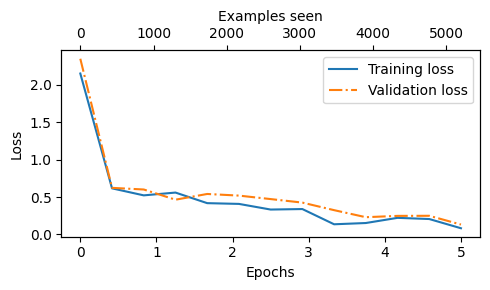

In [58]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    #1
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    #2
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0) #3
    ax2.set_xlabel("Examples seen")

    fig.tight_layout() #4
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses)).cpu().numpy()
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses)).cpu().numpy()

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

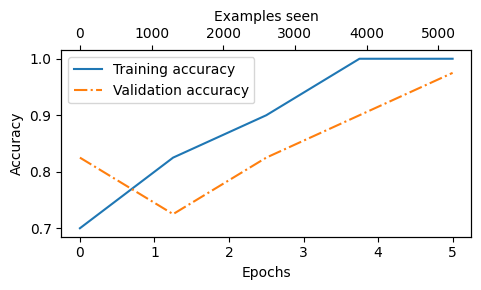

In [59]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [60]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 95.97%
Test accuracy: 96.33%


## 6.8 Using the LLM as a spam classifier

In [61]:
# 数据处理，类似SpamDataset
def classify_review(text, model, tokenizer, device, max_length=None, padded_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_max_lentgh = model.pos_emb.weight.shape[0] # 书里好像错了，应该是[0]取1024，代表最长token数量
    input_ids = input_ids[:min(supported_max_lentgh, max_length)] # 如果超长需要截断
    # 注意+后面不要放在[]中，否则嵌套list会导致出错
    padded_token_ids = input_ids + [padded_token_id] * (max_length - len(input_ids))
    # 转二维，添加batch维度
    input_tensor = torch.tensor(padded_token_ids, device=device).unsqueeze(0)
    # 推理不需要跟踪梯度
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    print(logits)
    predicted_label = logits.argmax(dim=-1).item()
    return "spam" if predicted_label else "not spam"

In [62]:
text_1 = (
"You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award."
)

print(classify_review(text_1, model, tokenizer, device,
                      max_length=train_dataset.max_length
))

tensor([[0.3935, 0.8905]], device='cuda:0')
spam


In [63]:
text_2 = (
"Hey, just wanted to check if we're still on"
" for dinner tonight? Let me know!"
)
print(classify_review(
text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

tensor([[ 2.5016, -1.4145]], device='cuda:0')
not spam


In [64]:
text_3 = (
"Classification fine-tuning involves replacing the output layer of an LLM via a small classification layer."
)
print(classify_review(
text_3, model, tokenizer, device, max_length=train_dataset.max_length
))

tensor([[ 1.6297, -0.6069]], device='cuda:0')
not spam


In [65]:
torch.save(model.state_dict(), "review_classifier.pth")

In [66]:
def load_classifier_weights():
    model_state_dict = torch.load("review_classifier.pth, map_location=device")
    model.load_state_dict(model_state_dict)

### 准确率没问题，但是测试用例全部spam?

注意填充的padding token id！！！！


训练时用 5026 填充，推理时用 50256 填充，模型在训练中学到了 5026 是 padding 的语义，推理时看到一堆 50256 就完全蒙了，输出退化成固定预测 spam。

需要重新训练！

```python
# ❌ 训练时
class SpamDataset(Dataset):
    def __init__(self, ..., pad_token_id=5026):   # typo！少了一个 2

# ✅ 推理时
def classify_review1(..., pad_token_id=50256):    # 正确的 GPT-2 eos token
```

### Exercise 6.2 Fine-tuning the whole model

In [69]:
for param in model.parameters():    # 解冻全部参数
    param.requires_grad = True

In [70]:
train_loop()

Ep 1 (Step 000000): Train loss 5.535, Val loss 2.679
Ep 1 (Step 000050): Train loss 0.020, Val loss 0.098
Ep 1 (Step 000100): Train loss 0.020, Val loss 0.077
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 2 (Step 000150): Train loss 0.015, Val loss 0.055
Ep 2 (Step 000200): Train loss 0.001, Val loss 0.010
Ep 2 (Step 000250): Train loss 0.002, Val loss 0.022
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 3 (Step 000300): Train loss 0.001, Val loss 0.039
Ep 3 (Step 000350): Train loss 0.000, Val loss 0.085
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.002, Val loss 0.012
Ep 4 (Step 000450): Train loss 0.000, Val loss 0.013
Ep 4 (Step 000500): Train loss 0.001, Val loss 0.077
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 5 (Step 000550): Train loss 0.183, Val loss 0.001
Ep 5 (Step 000600): Train loss 0.000, Val loss 0.001
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 2.6

In [71]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 100.00%
Validation accuracy: 95.97%
Test accuracy: 97.33%


对比原来只训练最后一个Transformer块，在整个模型上训练可以使准确率得到提升

只训练最后一个Transformer块和输出头：
```
Training accuracy: 97.21%
Validation accuracy: 95.97%
Test accuracy: 96.33%
```

在整个模型上训练：
```
Training accuracy: 100.00%
Validation accuracy: 95.97%
Test accuracy: 97.33%
```